# CNN

- 공간정보를 보존하기 위해 일부 연결을 끊은 뉴럴 네트워크
- 입출력데이터를 피처 맵으로 표현


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

## 합성곱

- 피처 맵 위의 필터를 스트라이드해가며 겹친 피처맵의 값을 필터의 값으로 가중 합산
  - 피처맵 - 입력 데이터 $(H, W)$
  - 필터 - 학습 대상 $(FH, FW)$
  - 패딩 - 피처맵 상하좌우에 측정 값으로 채워진 구간 $P$
  - 스트라이드 - 필터가 이동할 거리 $S$
  - 출력 피처맵 크기 $$(OH, OW) = \big(\frac{H+2P-FH}{S} + 1, \frac{W+2P-FW}{S} + 1\big)$$
- 필터 개수만큼의 편향


### 3차원

- $(C, H, W)$
- 필터와 입력의 채널 개수가 같아야 함
- 채널마다 수행하고 합산


### 전체 차원 흐름

- $$(N, C, H, W)*(FN, C, FH, FW) + (FN, 1, 1) \to (N, FN, OH, OW)$$


### im2col

- 필터 적용 영역 별로 한 행으로 펼쳐서 계산
- 단일 행렬 연산으로 바꾸어 연산 속도 증대
- 필터 영역 겹치면 중복 값 생성 - 메모리 소비 증가


In [ ]:
def im2col(
    input_data, fh, fw, stride=1, pad=0
):  # (N C H W), (FH FW) -> (N*OH*OW C*FH*FW)
    N, C, H, W = input_data.shape
    out_h = (H + 2 * pad - fh) // stride + 1
    out_w = (W + 2 * pad - fw) // stride + 1

    img = np.pad(input_data, [(0, 0), (0, 0), (pad, pad), (pad, pad)], "constant")
    col = np.zeros((N, C, fh, fw, out_h, out_w))

    for y in range(fh):
        y_max = y + stride * out_h
        for x in range(fw):
            x_max = x + stride * out_w
            col[:, :, y, x, :, :] = img[:, :, y:y_max:stride, x:x_max:stride]

    col = col.transpose(0, 4, 5, 1, 2, 3).reshape(
        N * out_h * out_w, -1
    )  # (N C FH FW OH OW) -> (N OH OW C FH FW)
    return col

### col2im


In [ ]:
def col2im(
    col, input_shape, fh, fw, stride=1, pad=0
):  # (N*OH*OW C*FH*FW) -> (N C H W), (FH FW)
    N, C, H, W = input_shape
    out_h = (H + 2 * pad - fh) // stride + 1
    out_w = (W + 2 * pad - fw) // stride + 1
    col = col.reshape(N, out_h, out_w, C, fh, fw).transpose(
        0, 3, 4, 5, 1, 2
    )  # (N OH OW C FH FW) -> (N C FH FW OH OW)

    img = np.zeros((N, C, H + 2 * pad + stride - 1, W + 2 * pad + stride - 1))
    for y in range(fh):
        y_max = y + stride * out_h
        for x in range(fw):
            x_max = x + stride * out_w
            img[:, :, y:y_max:stride, x:x_max:stride] += col[:, :, y, x, :, :]

    return img[:, :, pad : H + pad, pad : W + pad]

In [5]:
x = np.random.rand(10, 3, 7, 7)
col = im2col(x, 5, 5, 1, 0)
col.shape

(90, 75)

In [ ]:
class Conv:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

        self.x = None
        self.col = None
        self.col_W = None

        self.dW = None
        self.db = None

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        S, P = self.stride, self.pad

        OH = int(1 + (H + 2 * P - FH) / S)
        OW = int(1 + (W + 2 * P - FW) / S)

        col = im2col(x, FH, FW, S, P)
        col_W = self.W.reshape(FN, -1).T  # (FN, C, FH, FW) -> (C*FH*FW FN)
        out = (
            col @ col_W + self.b
        )  # (N*OH*OW C*FH*FW) * (C*FH*FW FN) + (1, FN)-> (N*OH*OW FN)

        out = out.reshape(N, OH, OW, -1).transpose(
            0, 3, 1, 2
        )  # (N*OH*OW FN) -> (N FN OH OW)

        self.x = x
        self.col = col
        self.col_W = col_W

        return out

    def backward(self, dout):
        FN, C, FH, FW = self.W.shape
        dout = dout.transpose(0, 2, 3, 1).reshape(-1, FN)

        self.db = np.sum(dout, axis=0)
        self.dW = np.dot(self.col.T, dout)
        self.dW = self.dW.transpose(1, 0).reshape(FN, C, FH, FW)

        dcol = np.dot(dout, self.col_W.T)
        dx = col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad)

        return dx

## 풀링

- 가로, 세로방향 공간을 줄이는 연산
- 특정 공간을 집계하여 축소 - 평균, 최대
- 학습 없음
- 채널 수 불변 - 채널별 연산
- 강건성 - 입력 데이터의 작은 변화 흡수


In [ ]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=2, pad=0):
        self.PH = pool_h
        self.PW = pool_w
        self.stride = stride
        self.pad = pad

        self.x = None
        self.arg_max = None

    def forward(self, x):
        N, C, H, W = x.shape
        PH, PW, S, P = self.PH, self.PW, self.stride, self.pad

        OH = int(1 + (H + 2 * P - PH) / S)
        OW = int(1 + (W + 2 * P - PW) / S)

        col = im2col(x, PH, PW, S, P)  # (N*OH*OW C*PH*PW)
        col = col.reshape(-1, PH * PW)  # (N*OH*OW*C PH*PW)

        arg_max = np.argmax(col, axis=1)
        out = np.max(col, axis=1)  # (N*OH*OW*C 1)
        out = out.reshape(N, OH, OW, C).transpose(
            0, 3, 1, 2
        )  # (N OH OW C) -> (N C OH OW)

        self.x = x
        self.arg_max = arg_max

        return out

    def backward(self, dout):
        dout = dout.transpose(0, 2, 3, 1)

        pool_size = self.PH * self.PW
        dmax = np.zeros((dout.size, pool_size))
        dmax[np.arange(self.arg_max.size), self.arg_max.flatten()] = dout.flatten()
        dmax = dmax.reshape(dout.shape + (pool_size,))

        dcol = dmax.reshape(dmax.shape[0] * dmax.shape[1] * dmax.shape[2], -1)
        dx = col2im(dcol, self.x.shape, self.PH, self.PW, self.stride, self.pad)

        return dx

## CNN


In [ ]:
import pickle
from collections import OrderedDict

from b1.module.layers import Affine, Relu, SoftmaxWithLoss


class SimpleConvNet:
    def __init__(
        self,
        input_dim=(1, 28, 28),
        conv_param={"filter_num": 30, "filter_size": 5, "pad": 0, "stride": 1},
        hidden_size=100,
        output_size=10,
        weight_init_std=0.01,
    ):
        filter_num = conv_param["filter_num"]
        filter_size = conv_param["filter_size"]
        filter_pad = conv_param["pad"]
        filter_stride = conv_param["stride"]
        input_size = input_dim[1]
        conv_output_size = (
            input_size - filter_size + 2 * filter_pad
        ) / filter_stride + 1
        pool_output_size = int(
            filter_num * (conv_output_size / 2) * (conv_output_size / 2)
        )

        self.params = {}
        self.params["W1"] = weight_init_std * np.random.randn(
            filter_num, input_dim[0], filter_size, filter_size
        )
        self.params["b1"] = np.zeros(filter_num)
        self.params["W2"] = weight_init_std * np.random.randn(
            pool_output_size, hidden_size
        )
        self.params["b2"] = np.zeros(hidden_size)
        self.params["W3"] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params["b3"] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers["Conv1"] = Conv(
            self.params["W1"],
            self.params["b1"],
            conv_param["stride"],
            conv_param["pad"],
        )
        self.layers["Relu1"] = Relu()
        self.layers["Pool1"] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers["Affine1"] = Affine(self.params["W2"], self.params["b2"])
        self.layers["Relu2"] = Relu()
        self.layers["Affine2"] = Affine(self.params["W3"], self.params["b3"])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1:
            t = np.argmax(t, axis=1)

        acc = 0.0

        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i * batch_size : (i + 1) * batch_size]
            tt = t[i * batch_size : (i + 1) * batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt)

        return acc / x.shape[0]

    def gradient(self, x, t):
        self.loss(x, t)

        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads["W1"], grads["b1"] = self.layers["Conv1"].dW, self.layers["Conv1"].db
        grads["W2"], grads["b2"] = self.layers["Affine1"].dW, self.layers["Affine1"].db
        grads["W3"], grads["b3"] = self.layers["Affine2"].dW, self.layers["Affine2"].db

        return grads

    def save_params(self, file_name="params/simple_conv_params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, "wb") as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params/simple_conv_params.pkl"):
        with open(file_name, "rb") as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(["Conv1", "Affine1", "Affine2"]):
            self.layers[key].W = self.params["W" + str(i + 1)]
            self.layers[key].b = self.params["b" + str(i + 1)]

In [ ]:
from datasets.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(
    normalize=True, one_hot_label=True, flatten=False
)


In [ ]:
from b1.module.trainer import Trainer

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100

net = SimpleConvNet()

trainer = Trainer(
    net,
    x_train,
    t_train,
    x_test,
    t_test,
    epochs=max_epochs,
    mini_batch_size=100,
    optimizer="Adam",
    optimizer_param={"lr": 0.001},
    evaluate_sample_num_per_epoch=1000,
)
trainer.train()

train loss:2.298278840074459
train loss:2.295150169611204
train loss:2.292894180600351
train loss:2.283967571063384
train loss:2.2747325211721465
train loss:2.2678019487826644
train loss:2.2479318392856387
train loss:2.2285912699342836
train loss:2.218520431243337
train loss:2.1927584297374345
train loss:2.1382680093695847
train loss:2.109254933954769
train loss:2.0607563576639616
train loss:2.043457730505892
train loss:1.9587281410376278
train loss:1.9238835899227413
train loss:1.802623735074788
train loss:1.8821752814734913
train loss:1.7028767920022556
train loss:1.6971245565852378
train loss:1.5611672990946805
train loss:1.4987957444211206
train loss:1.4372083939508633
train loss:1.3093509034370459
train loss:1.3064849209394154
train loss:1.1296820181918619
train loss:1.1610205410224397
train loss:1.1161812400565934
train loss:0.973210213287845
train loss:1.0431943326537572
train loss:0.9640403018267183
train loss:0.7022718066890523
train loss:0.8033014656846623
train loss:0.776990

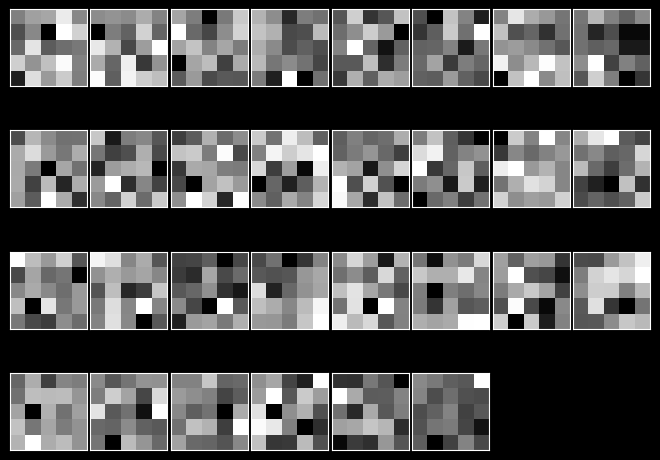

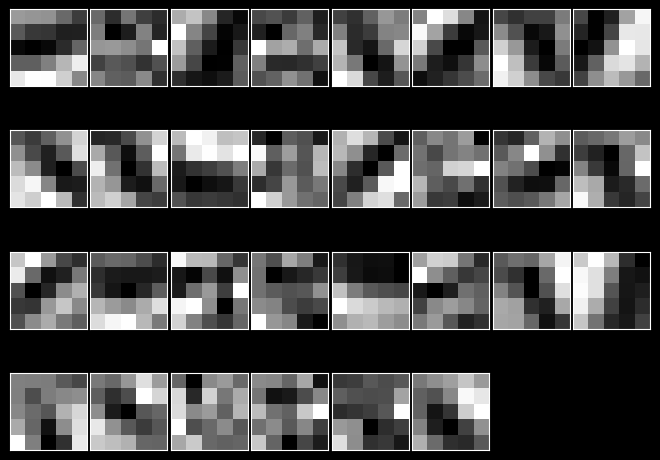

In [ ]:
def filter_show(filters, nx=8, margin=3, scale=10):
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i + 1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation="nearest")
    plt.show()


filter_show(SimpleConvNet().params["W1"])

filter_show(net.params["W1"])